In [9]:
import os
import re
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR
from skimage.metrics import peak_signal_noise_ratio as calculate_psnr
from skimage.metrics import structural_similarity as calculate_ssim
from tqdm.notebook import tqdm

# Set compute device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Running on device: {device}")

⚡ Running on device: cuda


In [10]:
!pip install torchmetrics

In [11]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset


class NTURainDataset(Dataset):

  def __init__(self, root_dir, patch_size=256, is_train=True):
    self.patch_size = patch_size
    self.is_train = is_train
    self.paired_files = []

    if not os.path.exists(root_dir):
      raise FileNotFoundError(f"Directory not found: '{root_dir}'")

    sequence_folders = sorted([
        f
        for f in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, f))
    ])

    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

    for seq in sequence_folders:
      seq_path = os.path.join(root_dir, seq)
      rf_dir = os.path.join(seq_path, 'rfc')
      gt_dir = os.path.join(seq_path, 'gtc')

      if os.path.exists(rf_dir) and os.path.exists(gt_dir):
        rf_files = sorted([
            f
            for f in os.listdir(rf_dir)
            if f.lower().endswith(valid_extensions)
        ])
        gt_files = sorted([
            f
            for f in os.listdir(gt_dir)
            if f.lower().endswith(valid_extensions)
        ])

        for rf_fname, gt_fname in zip(rf_files, gt_files):
          self.paired_files.append((
              os.path.join(rf_dir, rf_fname),
              os.path.join(gt_dir, gt_fname),
          ))

    print(
        f"✅ LOADED NEW DATASET: {len(self.paired_files)} pairs |"
        f" is_train={self.is_train} | patch_size={self.patch_size}"
    )

  def __len__(self):
    return len(self.paired_files)

  def __getitem__(self, idx):
    rf_path, gt_path = self.paired_files[idx]

    rainy_bgr = cv2.imread(rf_path)
    clean_bgr = cv2.imread(gt_path)

    if rainy_bgr is None or clean_bgr is None:
      raise ValueError(f"Error loading image pair: {rf_path} | {gt_path}")

    # Convert to YCrCb
    rainy_ycrcb = cv2.cvtColor(rainy_bgr, cv2.COLOR_BGR2YCrCb)
    clean_ycrcb = cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2YCrCb)

    r_y, r_cr, r_cb = cv2.split(rainy_ycrcb)
    c_y, _, _ = cv2.split(clean_ycrcb)

    # Force all training patches to strictly [patch_size, patch_size]
    if self.is_train and self.patch_size is not None:
      h, w = r_y.shape

      # 1. Pad reflectively if smaller than target patch_size
      pad_h = max(0, self.patch_size - h)
      pad_w = max(0, self.patch_size - w)

      if pad_h > 0 or pad_w > 0:
        r_y = cv2.copyMakeBorder(r_y, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
        c_y = cv2.copyMakeBorder(c_y, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
        r_cr = cv2.copyMakeBorder(r_cr, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
        r_cb = cv2.copyMakeBorder(r_cb, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
        h, w = r_y.shape

      # 2. Random crop guaranteed to yield [patch_size, patch_size]
      x = np.random.randint(0, w - self.patch_size + 1)
      y = np.random.randint(0, h - self.patch_size + 1)

      r_y = r_y[y : y + self.patch_size, x : x + self.patch_size]
      c_y = c_y[y : y + self.patch_size, x : x + self.patch_size]
      r_cr = r_cr[y : y + self.patch_size, x : x + self.patch_size]
      r_cb = r_cb[y : y + self.patch_size, x : x + self.patch_size]

    # Convert to Tensors
    r_tensor = (
        torch.from_numpy(np.ascontiguousarray(r_y)).float().unsqueeze(0) / 255.0
    )
    c_tensor = (
        torch.from_numpy(np.ascontiguousarray(c_y)).float().unsqueeze(0) / 255.0
    )
    chrom_tensor = torch.from_numpy(
        np.ascontiguousarray(np.stack((r_cr, r_cb), axis=0))
    )

    return r_tensor, c_tensor, chrom_tensor


# ==========================================
# RE-INITIALIZE DATASETS & LOADERS
# ==========================================
BASE_DIR = (
    '/kaggle/input/datasets/workrababu/lightdataset/frames_light_dataset'
)
train_dir = os.path.join(BASE_DIR, 'frames_light_train_JPEG')
test_dir = os.path.join(BASE_DIR, 'frames_light_test_JPEG')

train_dataset = NTURainDataset(
    root_dir=train_dir, patch_size=256, is_train=True
)
test_dataset = NTURainDataset(
    root_dir=test_dir, patch_size=None, is_train=False
)

train_loader = DataLoader(
    train_dataset, batch_size=16, shuffle=True, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False, num_workers=0
)

✅ LOADED NEW DATASET: 1431 pairs | is_train=True | patch_size=256
✅ LOADED NEW DATASET: 775 pairs | is_train=False | patch_size=None


In [12]:
import os

print(f"🔍 Inspecting: {train_dir}\n")

if os.path.exists(train_dir):
  items = os.listdir(train_dir)
  print(f"Found {len(items)} items inside 'train_dir': {items[:10]}")

  # Check inside the first item
  if len(items) > 0:
    first_item = os.path.join(train_dir, items[0])
    if os.path.isdir(first_item):
      print(f"\nInside '{items[0]}': {os.listdir(first_item)}")
else:
  print("❌ Folder path does not exist!")

🔍 Inspecting: /kaggle/input/datasets/workrababu/lightdataset/frames_light_dataset/frames_light_train_JPEG

Found 159 items inside 'train_dir': ['7', '135', '47', '17', '81', '19', '121', '22', '2', '147']

Inside '7': ['rfc', 'gtc']


In [13]:
class NTURainDataset(Dataset):

  def __init__(self, root_dir, patch_size=256, is_train=True):
    self.patch_size = patch_size
    self.is_train = is_train
    self.paired_files = []

    if not os.path.exists(root_dir):
      raise FileNotFoundError(f"Directory not found: '{root_dir}'")

    # Sequence folders ('7', '135', '47', etc.)
    sequence_folders = sorted([
        f
        for f in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, f))
    ])

    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

    for seq in sequence_folders:
      seq_path = os.path.join(root_dir, seq)
      rf_dir = os.path.join(seq_path, 'rfc')
      gt_dir = os.path.join(seq_path, 'gtc')

      if os.path.exists(rf_dir) and os.path.exists(gt_dir):
        rf_files = sorted([
            f
            for f in os.listdir(rf_dir)
            if f.lower().endswith(valid_extensions)
        ])
        gt_files = sorted([
            f
            for f in os.listdir(gt_dir)
            if f.lower().endswith(valid_extensions)
        ])

        # Pair frames 1-to-1 by sorted order (solves filename mismatch)
        for rf_fname, gt_fname in zip(rf_files, gt_files):
          rf_path = os.path.join(rf_dir, rf_fname)
          gt_path = os.path.join(gt_dir, gt_fname)
          self.paired_files.append((rf_path, gt_path))

    if len(self.paired_files) == 0:
      print(f"❌ ERROR: Still found 0 pairs in {root_dir}.")
    else:
      print(
          f"✅ Successfully loaded {len(self.paired_files)} paired frames across"
          f" {len(sequence_folders)} video sequences from"
          f" '{os.path.basename(root_dir)}'"
      )

  def __len__(self):
    return len(self.paired_files)

  def __getitem__(self, idx):
    rf_path, gt_path = self.paired_files[idx]

    rainy_bgr = cv2.imread(rf_path)
    clean_bgr = cv2.imread(gt_path)

    if rainy_bgr is None or clean_bgr is None:
      raise ValueError(f"Error loading image pair: {rf_path} | {gt_path}")

    # Convert to YCrCb color space
    rainy_ycrcb = cv2.cvtColor(rainy_bgr, cv2.COLOR_BGR2YCrCb)
    clean_ycrcb = cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2YCrCb)

    r_y, r_cr, r_cb = cv2.split(rainy_ycrcb)
    c_y, _, _ = cv2.split(clean_ycrcb)

    # Random crop during training
    if self.is_train and self.patch_size is not None:
      h, w = r_y.shape
      if h > self.patch_size and w > self.patch_size:
        x = np.random.randint(0, w - self.patch_size)
        y = np.random.randint(0, h - self.patch_size)

        r_y = r_y[y : y + self.patch_size, x : x + self.patch_size]
        c_y = c_y[y : y + self.patch_size, x : x + self.patch_size]
        r_cr = r_cr[y : y + self.patch_size, x : x + self.patch_size]
        r_cb = r_cb[y : y + self.patch_size, x : x + self.patch_size]

    # Normalize Y channel to [0, 1] Tensor
    r_tensor = torch.from_numpy(r_y).float().unsqueeze(0) / 255.0
    c_tensor = torch.from_numpy(c_y).float().unsqueeze(0) / 255.0

    chrominance = np.dstack((r_cr, r_cb))

    return r_tensor, c_tensor, chrominance


# ==========================================
# VERIFIED DATASET PATHS
# ==========================================
BASE_DIR = (
    '/kaggle/input/datasets/workrababu/lightdataset/frames_light_dataset'
)

train_dir = os.path.join(BASE_DIR, 'frames_light_train_JPEG')
test_dir = os.path.join(BASE_DIR, 'frames_light_test_JPEG')

# Create Datasets & DataLoaders
train_dataset = NTURainDataset(
    root_dir=train_dir, patch_size=256, is_train=True
)
test_dataset = NTURainDataset(
    root_dir=test_dir, patch_size=None, is_train=False
)

train_loader = DataLoader(
    train_dataset, batch_size=16, shuffle=True, num_workers=2
)
test_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False, num_workers=1
)

✅ Successfully loaded 1431 paired frames across 159 video sequences from 'frames_light_train_JPEG'
✅ Successfully loaded 775 paired frames across 25 video sequences from 'frames_light_test_JPEG'


In [14]:
class CALayer(nn.Module):

  def __init__(self, channel, reduction=16):
    super(CALayer, self).__init__()
    self.avg_pool = nn.AdaptiveAvgPool2d(1)
    self.conv_du = nn.Sequential(
        nn.Conv2d(channel, channel // reduction, 1, padding=0, bias=True),
        nn.ReLU(inplace=True),
        nn.Conv2d(channel // reduction, channel, 1, padding=0, bias=True),
        nn.Sigmoid(),
    )

  def forward(self, x):
    y = self.avg_pool(x)
    y = self.conv_du(y)
    return x * y


class RCAB(nn.Module):

  def __init__(self, channels, reduction=16):
    super(RCAB, self).__init__()
    self.body = nn.Sequential(
        nn.Conv2d(channels, channels, 3, padding=1, bias=True),
        nn.ReLU(inplace=True),
        nn.Conv2d(channels, channels, 3, padding=1, bias=True),
        CALayer(channels, reduction),
    )

  def forward(self, x):
    return x + self.body(x)


class HighPrecisionDerainNet(nn.Module):

  def __init__(self, in_channels=1, out_channels=1, channels=64, blocks=20):
    super(HighPrecisionDerainNet, self).__init__()
    self.head = nn.Conv2d(in_channels, channels, 3, padding=1, bias=True)

    body_layers = [RCAB(channels) for _ in range(blocks)]
    body_layers.append(
        nn.Conv2d(channels, channels, 3, padding=1, bias=True)
    )
    self.body = nn.Sequential(*body_layers)

    self.tail = nn.Conv2d(channels, out_channels, 3, padding=1, bias=True)

  def forward(self, x):
    feats = self.head(x)
    res = self.body(feats)
    res = res + feats
    out = self.tail(res)
    return out


model = HighPrecisionDerainNet(blocks=20, channels=64).to(device)
print(
    f"🧠 Model Initialized with {sum(p.numel() for p in model.parameters()):,} parameters."
)

🧠 Model Initialized with 1,526,865 parameters.


In [15]:
class CharbonnierLoss(nn.Module):

  def __init__(self, eps=1e-3):
    super(CharbonnierLoss, self).__init__()
    self.eps2 = eps**2

  def forward(self, x, y):
    return torch.mean(torch.sqrt((x - y) ** 2 + self.eps2))


class HybridDerainLoss(nn.Module):

  def __init__(self, alpha=0.8):
    super(HybridDerainLoss, self).__init__()
    self.charbonnier = CharbonnierLoss()
    self.alpha = alpha

  def forward(self, pred, target):
    c_loss = self.charbonnier(pred, target)

    # Structural Cosine Similarity Loss
    pred_flat = pred.view(pred.size(0), -1)
    target_flat = target.view(target.size(0), -1)
    cos_sim = F.cosine_similarity(pred_flat, target_flat, dim=1)
    struct_loss = torch.mean(1.0 - cos_sim)

    return self.alpha * c_loss + (1.0 - self.alpha) * struct_loss


criterion = HybridDerainLoss(alpha=0.8)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 100
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

In [16]:
import gc
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
from torchmetrics import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

# 1. HARD CLEAR VRAM
gc.collect()
torch.cuda.empty_cache()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# 2. EMBEDDED DATASET CLASS
class NTURainDataset(Dataset):
    def __init__(self, root_dir, patch_size=256, is_train=True):
        self.patch_size = patch_size
        self.is_train = is_train
        self.paired_files = []

        if not os.path.exists(root_dir):
            raise FileNotFoundError(f"Directory not found: '{root_dir}'")

        sequence_folders = sorted([
            f for f in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, f))
        ])
        valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

        for seq in sequence_folders:
            seq_path = os.path.join(root_dir, seq)
            rf_dir = os.path.join(seq_path, 'rfc')
            gt_dir = os.path.join(seq_path, 'gtc')

            if os.path.exists(rf_dir) and os.path.exists(gt_dir):
                rf_files = sorted([
                    f for f in os.listdir(rf_dir)
                    if f.lower().endswith(valid_extensions)
                ])
                gt_files = sorted([
                    f for f in os.listdir(gt_dir)
                    if f.lower().endswith(valid_extensions)
                ])

                for rf_fname, gt_fname in zip(rf_files, gt_files):
                    self.paired_files.append((
                        os.path.join(rf_dir, rf_fname),
                        os.path.join(gt_dir, gt_fname),
                    ))

    def __len__(self):
        return len(self.paired_files)

    def __getitem__(self, idx):
        rf_path, gt_path = self.paired_files[idx]

        rainy_bgr = cv2.imread(rf_path)
        clean_bgr = cv2.imread(gt_path)

        if rainy_bgr is None or clean_bgr is None:
            raise ValueError(f'Error loading image pair: {rf_path} | {gt_path}')

        rainy_ycrcb = cv2.cvtColor(rainy_bgr, cv2.COLOR_BGR2YCrCb)
        clean_ycrcb = cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2YCrCb)

        r_y, r_cr, r_cb = cv2.split(rainy_ycrcb)
        c_y, _, _ = cv2.split(clean_ycrcb)

        if self.patch_size is not None:
            h, w = r_y.shape
            pad_h = max(0, self.patch_size - h)
            pad_w = max(0, self.patch_size - w)

            if pad_h > 0 or pad_w > 0:
                r_y = cv2.copyMakeBorder(r_y, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
                c_y = cv2.copyMakeBorder(c_y, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
                r_cr = cv2.copyMakeBorder(r_cr, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
                r_cb = cv2.copyMakeBorder(r_cb, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
                h, w = r_y.shape

            if self.is_train:
                x = np.random.randint(0, w - self.patch_size + 1)
                y = np.random.randint(0, h - self.patch_size + 1)
            else:
                x = (w - self.patch_size) // 2
                y = (h - self.patch_size) // 2

            r_y = r_y[y : y + self.patch_size, x : x + self.patch_size]
            c_y = c_y[y : y + self.patch_size, x : x + self.patch_size]
            r_cr = r_cr[y : y + self.patch_size, x : x + self.patch_size]
            r_cb = r_cb[y : y + self.patch_size, x : x + self.patch_size]

        r_tensor = torch.from_numpy(np.ascontiguousarray(r_y)).float().unsqueeze(0) / 255.0
        c_tensor = torch.from_numpy(np.ascontiguousarray(c_y)).float().unsqueeze(0) / 255.0
        chrom_tensor = torch.from_numpy(np.ascontiguousarray(np.stack((r_cr, r_cb), axis=0)))

        return r_tensor, c_tensor, chrom_tensor


# 3. INITIALIZE DATASET
BASE_DIR = '/kaggle/input/datasets/workrababu/lightdataset/frames_light_dataset'
train_dir = os.path.join(BASE_DIR, 'frames_light_train_JPEG')

train_dataset = NTURainDataset(root_dir=train_dir, patch_size=256, is_train=True)

BATCH_SIZE = 2
ACCUM_STEPS = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# 4. MODEL, OPTIMIZER & SCALER
# (Assuming HighPrecisionDerainNet is defined earlier in your notebook)
model = HighPrecisionDerainNet(blocks=20, channels=64).to(device)
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

scaler = torch.cuda.amp.GradScaler()

# Initialize Metrics (Data range is 1.0 because tensors are scaled to [0, 1] in the dataset)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

epochs = 260
save_path = '/kaggle/working/high_precision_derain.pth'
best_loss = float('inf')

print(f'🚀 Training started on {device} (Micro-Batch: {BATCH_SIZE}, Effective Batch: {BATCH_SIZE * ACCUM_STEPS})...')

# 5. TRAINING LOOP
for epoch in range(1, epochs + 1):
    model.train()
    
    running_loss = 0.0
    running_psnr = 0.0
    running_ssim = 0.0
    
    optimizer.zero_grad()

    for step, (r_t, c_t, _) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch}/{epochs} [Train]')):
        r_t, c_t = r_t.to(device), c_t.to(device)

        with torch.cuda.amp.autocast():
            outputs = model(r_t)
            loss = criterion(outputs, c_t) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        # Track Loss
        running_loss += loss.item() * ACCUM_STEPS * r_t.size(0)

        # Track Metrics (Run inside torch.no_grad() to save VRAM and skip gradient calc)
        with torch.no_grad():
            # Clamp outputs to [0.0, 1.0] to prevent out-of-bounds values skewing PSNR/SSIM
            out_clamped = torch.clamp(outputs.detach(), 0.0, 1.0).float()
            c_t_float = c_t.float()
            
            running_psnr += psnr_metric(out_clamped, c_t_float).item() * r_t.size(0)
            running_ssim += ssim_metric(out_clamped, c_t_float).item() * r_t.size(0)

    # Calculate Epoch Averages
    epoch_loss = running_loss / len(train_dataset)
    epoch_psnr = running_psnr / len(train_dataset)
    epoch_ssim = running_ssim / len(train_dataset)
    
    print(f'Epoch {epoch}/{epochs} - Loss: {epoch_loss:.6f} | PSNR: {epoch_psnr:.2f} dB | SSIM: {epoch_ssim:.4f}')

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), save_path)
        print(f'  💾 Saved new best model to {save_path}')

print('✅ Training complete!')

🚀 Training started on cuda (Micro-Batch: 2, Effective Batch: 16)...


/tmp/ipykernel_58/4041268890.py:122: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `PeakSignalNoiseRatio` from `torchmetrics` was deprecated and will be removed in 2.0. Import `PeakSignalNoiseRatio` from `torchmetrics.image` instead.
  _future_warning(
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


Epoch 1/260 [Train]:   0%|          | 0/716 [00:00<?, ?it/s]

/tmp/ipykernel_58/4041268890.py:147: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/260 - Loss: 0.044210 | PSNR: 23.29 dB | SSIM: 0.7705
  💾 Saved new best model to /kaggle/working/high_precision_derain.pth


...

Epoch 258/260 - Loss: 0.005482 | PSNR: 37.20 dB | SSIM: 0.9776


Epoch 259/260 [Train]:   0%|          | 0/716 [00:00<?, ?it/s]

Epoch 259/260 - Loss: 0.005704 | PSNR: 37.08 dB | SSIM: 0.9773


Epoch 260/260 [Train]:   0%|          | 0/716 [00:00<?, ?it/s]

Epoch 260/260 - Loss: 0.005946 | PSNR: 37.04 dB | SSIM: 0.9774
✅ Training complete!


In [17]:
import torch

# Inside your training loop
for epoch in range(epochs):
    # ... your training code here ...
    
    # Save checkpoint at the end of the epoch
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }
    torch.save(checkpoint, '/kaggle/working/checkpoint.pth')


In [18]:
import os

if os.path.exists('/kaggle/working/checkpoint.pth'):
    print("Loading checkpoint...")
    checkpoint = torch.load('/kaggle/working/checkpoint.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
else:
    start_epoch = 0


Loading checkpoint...


✅ Loaded trained model weights for inference.


/tmp/ipykernel_58/2975511210.py:78: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/2975511210.py:78: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/2975511210.py:82: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.savefig(output_fig_path, bbox_inches='tight', dpi=300)
/tmp/ipykernel_58/2975511210.py:82: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(output_fig_path, bbox_inches='tight', dpi=300)


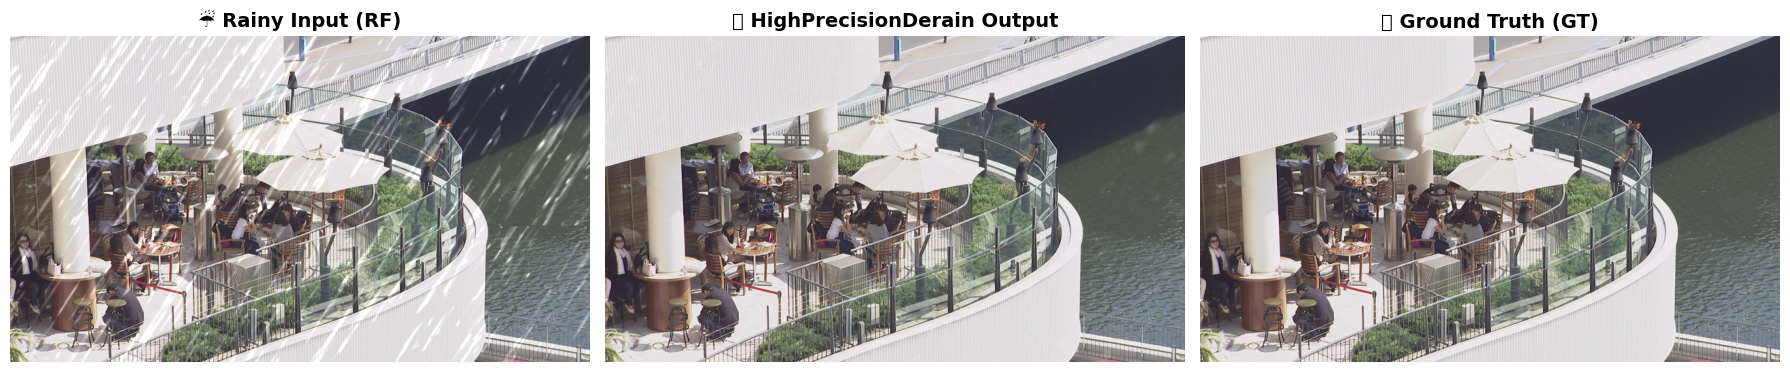

📷 Output visualization saved to: /kaggle/working/derain_result_sample.png


In [26]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Device and Model Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
save_path = '/kaggle/working/high_precision_derain.pth'

model = HighPrecisionDerainNet(blocks=20, channels=64).to(device)

if os.path.exists(save_path):
  model.load_state_dict(torch.load(save_path, map_location=device))
  print('✅ Loaded trained model weights for inference.')
else:
  print('⚠️ No saved model found! Running visual evaluation with current model.')

model.eval()

# 2. Re-initialize Test Dataset (if not in memory)
BASE_DIR = (
    '/kaggle/input/datasets/workrababu/lightdataset/frames_light_dataset'
)
test_dir = os.path.join(BASE_DIR, 'frames_light_train_JPEG')
test_dataset = NTURainDataset(
    root_dir=test_dir, patch_size=None, is_train=False
)

# 3. Select a Test Sample (Change index to test different images)
sample_idx = 0
r_tensor, c_tensor, chrom_tensor = test_dataset[sample_idx]

# Add batch dimension [1, 1, H, W] for model forward pass
r_input = r_tensor.unsqueeze(0).to(device)

# 4. Run Model Inference
with torch.no_grad():
  pred_y_tensor = model(r_input)
  # Clamp model outputs to valid [0, 1] range
  pred_y_tensor = torch.clamp(pred_y_tensor, 0.0, 1.0)

# 5. Convert Tensors back to NumPy uint8 arrays (0 - 255)
pred_y = (pred_y_tensor.squeeze().cpu().numpy() * 255.0).astype(np.uint8)
r_y = (r_tensor.squeeze().numpy() * 255.0).astype(np.uint8)
c_y = (c_tensor.squeeze().numpy() * 255.0).astype(np.uint8)

# Extract Chroma (Cr, Cb) channels
chrom = chrom_tensor.numpy().astype(np.uint8)
cr, cb = chrom[0], chrom[1]

# 6. Reconstruct YCrCb -> RGB Images
rainy_ycrcb = cv2.merge([r_y, cr, cb])
derained_ycrcb = cv2.merge([pred_y, cr, cb])
clean_ycrcb = cv2.merge([c_y, cr, cb])

rainy_rgb = cv2.cvtColor(rainy_ycrcb, cv2.COLOR_YCrCb2RGB)
derained_rgb = cv2.cvtColor(derained_ycrcb, cv2.COLOR_YCrCb2RGB)
clean_rgb = cv2.cvtColor(clean_ycrcb, cv2.COLOR_YCrCb2RGB)

# 7. Plot Side-by-Side Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rainy_rgb)
axes[0].set_title('☔ Rainy Input (RF)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(derained_rgb)
axes[1].set_title(
    '✨ HighPrecisionDerain Output', fontsize=14, fontweight='bold'
)
axes[1].axis('off')

axes[2].imshow(clean_rgb)
axes[2].set_title('🌟 Ground Truth (GT)', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()

# Save image grid to Kaggle working output directory
output_fig_path = '/kaggle/working/derain_result_sample.png'
plt.savefig(output_fig_path, bbox_inches='tight', dpi=300)
plt.show()

print(f'📷 Output visualization saved to: {output_fig_path}')

In [ ]:
# Path to input rainy video file
input_video_path = "/kaggle/input/your-rainy-video.mp4"  # Update with your input video path
output_video_path = "/kaggle/working/derained_output_video.mp4"

cap = cv2.VideoCapture(input_video_path)

if not cap.isOpened():
  print(f"❌ Error: Could not open video file at {input_video_path}")
else:
  width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
  height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
  fps = cap.get(cv2.CAP_PROP_FPS)
  total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

  fourcc = cv2.VideoWriter_fourcc(*"mp4v")
  video_writer = cv2.VideoWriter(
      output_video_path, fourcc, fps, (width, height)
  )

  print(
      f"🎬 Processing {total_frames} frames at {fps} FPS ({width}x{height})..."
  )

  best_model.eval()
  pbar = tqdm(total=total_frames, desc="Rendering Output Video")

  with torch.no_grad():
    while cap.isOpened():
      ret, frame_bgr = cap.read()
      if not ret:
        break

      # 1. Convert BGR to YCrCb
      ycrcb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)
      y_channel, cr_channel, cb_channel = cv2.split(ycrcb)

      # 2. Convert Y channel to float Tensor [1, 1, H, W]
      y_tensor = (
          torch.from_numpy(y_channel).float().unsqueeze(0).unsqueeze(0) / 255.0
      ).to(device)

      # 3. Predict Y channel
      pred_y_tensor = best_model(y_tensor)

      # 4. Format predicted Y back to uint8
      pred_y_np = (
          (pred_y_tensor.squeeze().cpu().numpy() * 255.0)
          .clip(0, 255)
          .astype(np.uint8)
      )

      if pred_y_np.shape != (height, width):
        pred_y_np = cv2.resize(
            pred_y_np, (width, height), interpolation=cv2.INTER_CUBIC
        )

      # 5. Merge restored Y channel with original chrominance
      derained_ycrcb = cv2.merge([pred_y_np, cr_channel, cb_channel])
      derained_bgr = cv2.cvtColor(derained_ycrcb, cv2.COLOR_YCrCb2BGR)

      # 6. Write frame
      video_writer.write(derained_bgr)
      pbar.update(1)

  pbar.close()
  cap.release()
  video_writer.release()

  print(f"✨ ALL DONE! Full video saved to: {output_video_path}")

❌ Error: Could not open video file at /kaggle/input/your-rainy-video.mp4
